In [142]:
#################################################################################
# Main script to run UP-MAVT analysis
#
# Simone Pagliuca, 2025-2026
#
# Description:
# TBC....
#################################################################################

#################################################################################
# Import third party libraries
import numpy as np
# import matplotlib
# matplotlib.use('TkAgg')  # Set backend before importing pyplot
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
#################################################################################

#################################################################################
# Import internal modules
from pile_bwt import bwt, constraints_func
from up_mavt import startup, mc_simulation
from aggregation_methods import weighted_sum
from weight_sampling import obtain_weight_space_description
#################################################################################

#################################################################################
# USER INPUTS
# Weight elicitation files (one per elicitation / run)
file_path_weight_elicitations = ["wbt_results_1.csv"]
file_path_weight_elicitations = ["wbt_results_alt.csv"]


# Value function files (one per elicitation / run)
file_path_value_functions = ["value_functions_1.csv"]

# Criteria definitions file
file_path_criteria = "criteria.csv"

# Montecarlo Parameters
n_runs = 10000
PLOTS = True  # Toggle plots
UPDATE_EVERY = 10  # Update plots every N runs
#################################################################################


#################################################################################
# Startup: Load all data
dict_data_list, crit_index, vf_list, alternatives = startup(file_path_criteria, file_path_weight_elicitations, file_path_value_functions)
n_alternatives = len(alternatives)
print(f"Loaded {len(dict_data_list)} elicitation(s) with {n_alternatives} alternatives.")
#################################################################################


Number of criteria identified: 15
Loading criteria definitions and attaching value functions...
Starting loop over weight elicitation files...
Processing file 1/1: wbt_results_alt.csv
Loaded 1 elicitation(s) with 6 alternatives.


In [143]:

#################################################################################
# PILE-BWT Method
# 
# Work in progress while we try to fix issues with constraints and solver
# For now it runs the BWT optimization and then tries to sample more values from the space
print("Running BWT for each elicitation...")
bwt_results = []

for i, dict_data in enumerate(dict_data_list):
    print(f"Running BWT for elicitation {i+1}...")  # Debugging: Print elicitation index
    bwt_result = bwt(dict_data)
    bwt_results.append(bwt_result)
    
print(bwt_result["solver_result"])



Running BWT for each elicitation...
Running BWT for elicitation 1...
Running optimization...
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 1.6727782395783364
           x: [ 8.179e-02  1.189e-01 ...  1.612e-01  1.673e+00]
         nit: 13
         jac: [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]
        nfev: 221
        njev: 12
 multipliers: [-5.086e-07  0.000e+00 ...  2.926e-01  0.000e+00]


In [144]:

print("\033[93mTesting with BWT results...\033[0m")
x_weights = bwt_result["solver_result"]["x"][:-1]
x_temp = np.concatenate([x_weights, [0]])
constraint_value = constraints_func(x_temp, dict_data)
error_b = min(max([abs(cv) for cv in constraint_value]), 10)
for c in constraint_value:
    c_py = float(c)
    print(c_py)  # Debugging: print as native Python float
print(f"\033[91mMaximum constraint violation (error_b): {error_b}\033[0m")  # Debugging
known_max_error = error_b
print("\n")
print(x_weights)


Testing with BWT results...
-0.4662781539662698
-0.4242745371868457
-1.4420724620399668
-1.672779443994718
-1.672779570416738
-0.5269156948757735
-0.143787379981263
-0.7173324083072838
-1.6727782294769131
-1.6727783148904343
-1.6727785789370815
-0.05625521917340337
-0.3069798872608729
-1.6417686919585954
-0.1483952078848343
-1.672778720532411
-1.6727787004353138
-0.6608190183419844
-0.961291546960565
-1.6727786688757198
-1.671106893739904
-1.672721590997241
-0.4160567493247188
-1.6727782712610144
-1.6727781366928896
-1.648962452917511
-1.6727782458602976
-1.6627238216065763
Maximum constraint violation (error_b): 1.672779570416738


[0.08178992 0.11894549 0.11209798 0.0383528  0.06009961 0.06368694
 0.04529664 0.01272184 0.08343612 0.06331941 0.00977204 0.05608175
 0.05534892 0.03781052 0.16124003]


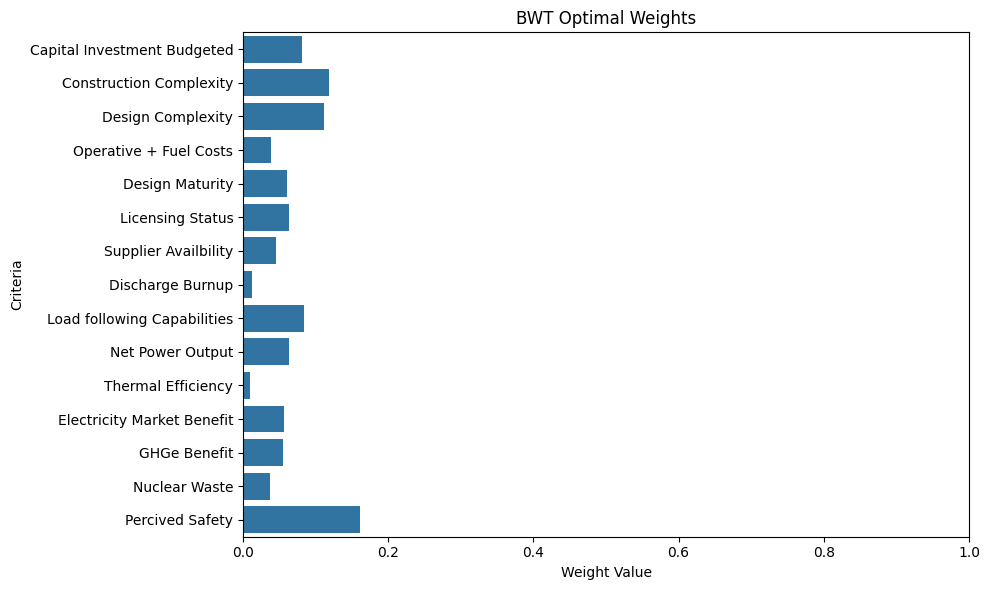

In [145]:
# Plot the BWT weights as horizontal bars
plt.figure(figsize=(10, 6))
sns.barplot(y=list(crit_index.keys()), x=x_weights, orient='h')
plt.title("BWT Optimal Weights")
plt.xlabel("Weight Value")
plt.ylabel("Criteria")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()
#################################################################################

In [146]:

from weight_sampling import obtain_weight_space_description
num_criteria = len(x_weights)
used_cells = set()
grid_size = np.int64(1000)
n_dimensions = num_criteria
# print("Number of dimensions for sampling:", n_dimensions)
nx = np.array([grid_size] * n_dimensions, dtype=np.int64)

initial_point = bwt_result["solver_result"]["x"][:num_criteria]
# print("Initial point for sampling:", initial_point)
initial_cell = tuple(np.clip((np.array(initial_point) * grid_size).astype(np.int64), 0, grid_size - 1))
used_cells.add(initial_cell)
valid_points = [np.array(initial_cell, dtype=np.float64) / grid_size]

print("Starting space sampling...")
print(f"Grid size: {grid_size}, Number of dimensions: {n_dimensions}")
print(f"Initial point: {initial_point}, Initial cell: {initial_cell}")


Starting space sampling...
Grid size: 1000, Number of dimensions: 15
Initial point: [0.08178992 0.11894549 0.11209798 0.0383528  0.06009961 0.06368694
 0.04529664 0.01272184 0.08343612 0.06331941 0.00977204 0.05608175
 0.05534892 0.03781052 0.16124003], Initial cell: (np.int64(81), np.int64(118), np.int64(112), np.int64(38), np.int64(60), np.int64(63), np.int64(45), np.int64(12), np.int64(83), np.int64(63), np.int64(9), np.int64(56), np.int64(55), np.int64(37), np.int64(161))


In [147]:
print(sum(initial_point))

1.0


In [148]:
print(known_max_error)

1.672779570416738


In [149]:
list_of_weight_space_points = obtain_weight_space_description(bwt_results, dict_data_list, file_path_weight_elicitations, crit_index)

Weight samples for elicitation 1 already exist. Reading from file...


In [150]:
# We then seelct one of the elicitated spaces
weight_space_points = list_of_weight_space_points[0]
print(weight_space_points)

[[0.082, 0.083, 0.084, 0.085, 0.086, 0.087, 0.088, 0.089, 0.09, 0.091, 0.092, 0.093, 0.094, 0.095, 0.096, 0.097, 0.098, 0.099, 0.1, 0.101, 0.102, 0.103, 0.104, 0.105, 0.106, 0.107, 0.108, 0.109, 0.11, 0.111, 0.112, 0.113, 0.114, 0.115, 0.116, 0.117, 0.118, 0.119, 0.12, 0.121, 0.122, 0.123, 0.124, 0.125, 0.126, 0.127, 0.128, 0.129, 0.13, 0.131, 0.132, 0.133, 0.134, 0.135, 0.136, 0.137, 0.138, 0.139, 0.14, 0.141, 0.142, 0.143, 0.144, 0.145, 0.146, 0.147, 0.148, 0.149, 0.15, 0.151, 0.152, 0.153, 0.154, 0.155, 0.156, 0.157, 0.158, 0.159, 0.16, 0.161, 0.162, 0.163, 0.164, 0.165, 0.166, 0.167, 0.168, 0.169, 0.17, 0.171, 0.172, 0.173, 0.174, 0.175, 0.176, 0.177, 0.178, 0.179, 0.18, 0.181, 0.182, 0.183, 0.184, 0.185, 0.186, 0.187, 0.188, 0.189, 0.19, 0.191, 0.192], [0.059, 0.06, 0.061, 0.062, 0.063, 0.064, 0.065, 0.066, 0.067, 0.068, 0.069, 0.07, 0.071, 0.072, 0.073, 0.074, 0.075, 0.076, 0.077, 0.078, 0.079, 0.08, 0.081, 0.082, 0.083, 0.084, 0.085, 0.086, 0.087, 0.088, 0.089, 0.09, 0.091, 0.09

In [151]:
from weight_sampling import weight_sampler
weight_sampler(dict_data, weight_space_points)

Sampled weights: [np.float64(0.085), np.float64(0.084), np.float64(0.112), np.float64(0.044), np.float64(0.077), np.float64(0.054), np.float64(0.072), np.float64(0.011), np.float64(0.081), np.float64(0.064), np.float64(0.01), np.float64(0.051), np.float64(0.055), np.float64(0.038), np.float64(0.161)], sum: 0.9990000000000001, constraints satisfied: [np.float64(-0.14199858382274977), np.float64(-0.3949747742989401), np.float64(-1.642821268688976), np.float64(-0.4805194805194808), np.float64(-1.295423279039678), np.float64(-0.04466230936819149), np.float64(-0.4011437908496729), np.float64(-0.09523809523809534), np.float64(-0.8318181818015562), np.float64(-1.531818181861094), np.float64(-0.867638341802162), np.float64(-0.00417800920455158), np.float64(-0.1312747054385266), np.float64(-1.7828947368421049), np.float64(-0.16487647690645346), np.float64(-1.9545520585866323), np.float64(-1.6868953496893457), np.float64(-0.6332385016595556), np.float64(-0.8840166369578135), np.float64(-1.080808

[np.float64(0.085),
 np.float64(0.084),
 np.float64(0.112),
 np.float64(0.044),
 np.float64(0.077),
 np.float64(0.054),
 np.float64(0.072),
 np.float64(0.011),
 np.float64(0.081),
 np.float64(0.064),
 np.float64(0.01),
 np.float64(0.051),
 np.float64(0.055),
 np.float64(0.038),
 np.float64(0.161)]

In [152]:
# read csv possible_solutions_unique_0.001.csv
with open("possible_solutions_unique_0.001.csv", mode='r') as file:
    # Skip header if present
    if file.readline().strip().replace(',', '').isalpha():
        file.seek(0)  # Reset to start if header was read
        next(file)  # Skip the header line

    csv_reader = csv.reader(file)
    possible_solutions = []
    for row in csv_reader:
        possible_solutions.append([float(value) for value in row])

found = False
while found == False:
    weight_set_candidate = possible_solutions[np.random.randint(len(possible_solutions))][:-1]
    total_weight = sum(weight_set_candidate)
    if not np.isclose(total_weight, 1.0, atol=1e-3):
        continue
    else:
        x_temp = np.concatenate((weight_set_candidate, [0]))
        constraints_satisfied = constraints_func(x_temp, dict_data)
        # print(f"Sampled weights: {weight_set_candidate}, sum: {total_weight}, constraints satisfied: {constraints_satisfied}")
        if not constraints_satisfied:
            continue
        else:
            found = True

print(f"Final selected weights: {weight_set_candidate}, ")
print(f"sum: {sum(weight_set_candidate)}")
# Check if all constraints are negative:
cons = constraints_func(np.concatenate((weight_set_candidate, [0])), dict_data)
if all(c <= 0 for c in cons):
    print("All constraints are satisfied.")
else:
    print("Some constraints are violated.")

Final selected weights: [0.653, 0.058, 0.058, 0.074, 0.001, 0.001, 0.001, 0.005, 0.05, 0.052, 0.038, 0.001, 0.001, 0.007, 0.001], 
sum: 1.0010000000000001
All constraints are satisfied.


In [160]:
# Check if all rows of the csv sum to 1 (exclude last column)
removed = 0
for row in possible_solutions:
    weight_sum = sum(row[:-1])
    if not np.isclose(weight_sum, 1.0, atol=1e-3):
        # Remove the row if it does not sum to 1
        possible_solutions.remove(row)
        removed += 1
print(f"Removed {removed} rows that did not sum to 1.")

Removed 0 rows that did not sum to 1.


In [161]:
# Check that all remaining rows satisfy the constraints
violations = 0
for row in possible_solutions:
    x_temp = np.concatenate((row[:-1], [0]))
    constraints_satisfied = constraints_func(x_temp, dict_data)
    if not constraints_satisfied:
        violations += 1
print(f"Found {violations} rows that violate the constraints.")

Found 0 rows that violate the constraints.


In [162]:
# Save possible solutions to csv
new_csv_name = "filtered_solutions"
with open(new_csv_name + ".csv", "w", newline='') as f:
    writer = csv.writer(f)
    # prepare ordered header from crit_index (index -> name)
    criteria_names = [name for name, _ in sorted(crit_index.items(), key=lambda x: x[1])]
    writer.writerow(criteria_names)
    for row in possible_solutions:
        # write only weight columns (exclude last objective/value column)
        writer.writerow([float(v) for v in row[:-1]])
print(f"Saved {len(possible_solutions)} solutions to {new_csv_name}.csv")

Saved 1578 solutions to filtered_solutions.csv


In [163]:
# Read filtered solution as pandas df
import pandas as pd
# Read all entries of the csv file into a DataFrame
df = pd.read_csv("./" + new_csv_name + ".csv")
# Refilter to ensure uniqueness (in case of multiple runs appending)
round_dec = 3
rounded = np.round(df.iloc[:, :-1].values, round_dec)
_, uniq_idx = np.unique(rounded, axis=0, return_index=True)
uniq_idx = np.sort(uniq_idx)
# Drop those with error (z > the others + 0.1)
z_values = df.iloc[uniq_idx, -1]
threshold = z_values.min() + 0.1
filtered_idx = uniq_idx[z_values <= 7.4436]

df = df.iloc[filtered_idx].reset_index(drop=True)

display(df)

,Capital Investment Budgeted,Construction Complexity,Design Complexity,Operative + Fuel Costs,Design Maturity,Licensing Status,Supplier Availbility,Discharge Burnup,Load following Capabilities,Net Power Output,Thermal Efficiency,Electricity Market Benefit,GHGe Benefit,Nuclear Waste,Percived Safety
0,0.653,0.058,0.058,0.074,0.001,0.001,0.001,0.005,0.050,0.052,0.038,0.001,0.001,0.007,0.001
1,0.651,0.058,0.058,0.074,0.003,0.001,0.001,0.005,0.050,0.052,0.038,0.001,0.001,0.007,0.001
2,0.617,0.055,0.062,0.070,0.001,0.001,0.001,0.004,0.047,0.049,0.036,0.002,0.001,0.053,0.001
3,0.062,0.004,0.004,0.005,0.001,0.001,0.001,0.026,0.004,0.276,0.610,0.001,0.001,0.002,0.001
4,0.651,0.058,0.060,0.074,0.001,0.001,0.001,0.005,0.050,0.052,0.038,0.001,0.001,0.007,0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
816,0.620,0.105,0.055,0.070,0.001,0.001,0.001,0.004,0.047,0.049,0.036,0.001,0.001,0.007,0.001
817,0.229,0.109,0.076,0.025,0.043,0.020,0.185,0.001,0.017,0.047,0.012,0.086,0.086,0.032,0.032
818,0.126,0.008,0.008,0.247,0.001,0.001,0.002,0.024,0.022,0.001,0.220,0.238,0.001,0.100,0.001
819,0.609,0.098,0.054,0.069,0.001,0.001,0.001,0.004,0.046,0.072,0.035,0.001,0.001,0.006,0.001


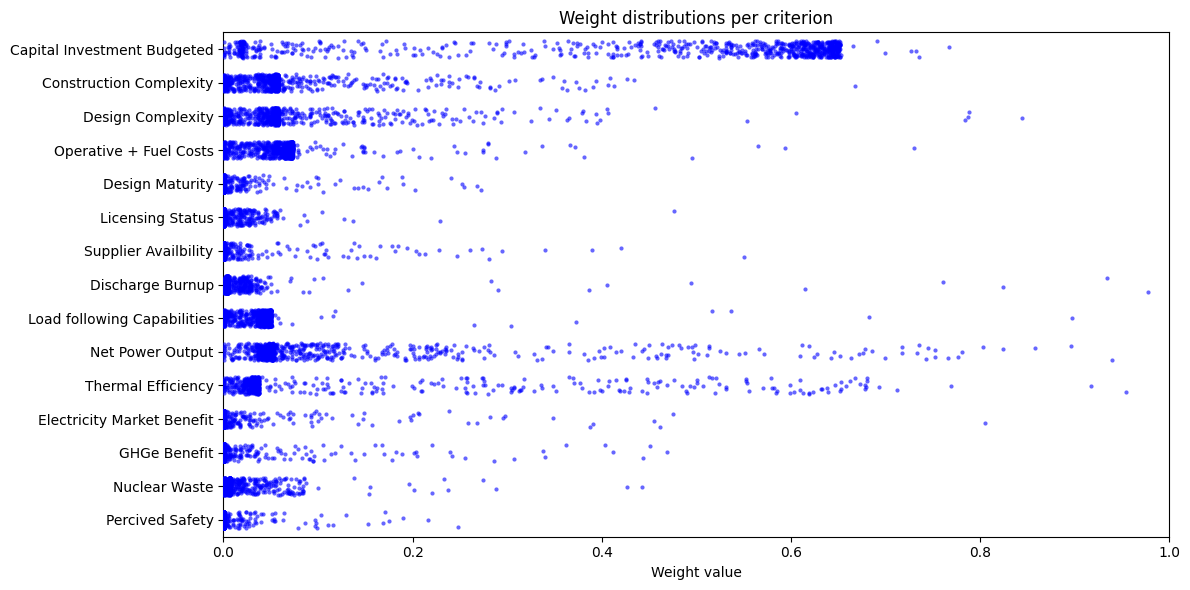

In [164]:
# Plot
plt.figure(figsize=(12, 6))
sns.stripplot(data=df, orient='h', color='b', size=3, jitter=0.25, alpha=0.6)
plt.xlabel('Weight value')
plt.title('Weight distributions per criterion')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()